# Basic Data Cleaning  
Data cleaning is the process of identifying and correcting issues in raw data to improve its quality before analysis or training a Machine Learning model. Since real-world datasets are often incomplete, inconsistent, or inaccurate, cleaning the data is one of the most important steps in the Machine Learning pipeline.

Common data cleaning tasks include:

* Handling missing values.
* Removing duplicate records.
* Correcting inconsistent or incorrect data.
* Dealing with outliers.
* Converting data types into the correct format.
* Standardizing text, dates, and categorical values.

Clean data leads to more accurate analyses, better-performing models, and more reliable predictions.


In [14]:
import pandas as pd

In [15]:
# Reading the csv
df = pd.read_csv("Online Sales Data.csv")

In [16]:
df.head()

,Transaction ID,Date,Product Category,Product Name,Units Sold,Unit Price,Total Revenue,Region,Payment Method
0,10001,1/1/2024,Electronics,Iphone 14 Pro,2,999.99,1999.98,North America,Credit Card
1,10002,1/2/2024,Home Appliances,Dyson V11 Vacuum,1,NaN,499.99,Europe,PayPal
2,10003,1/3/2024,Clothing,Levi's 501 Jeans,3,69.99,209.97,Asia,Debit Card
3,10004,1/4/2024,Books,The Da Vinci Code,4,15.99,63.96,North America,NaN
4,10004,1/4/2024,Books,The Da Vinci Code,4,15.99,63.96,North America,NaN


In [17]:
# Checking for nulls
df.isna().sum()

Transaction ID      0
Date                0
Product Category    1
Product Name        0
Units Sold          0
Unit Price          1
Total Revenue       0
Region              0
Payment Method      2
dtype: int64

In [18]:
# Dropping the nulls
df.dropna(inplace=True) # inplace parameter applies the changes to the actual df 

In [19]:
# Dealing with duplicates
df.duplicated().sum()

np.int64(1)

In [20]:
# Dropping duplicates
df.drop_duplicates(inplace=True)

In [21]:
# Typecasting columns
df["Date"] = pd.to_datetime(df["Date"]) # for time intelligence
df["Transaction ID"] = df["Transaction ID"].astype("str") # to make IDs static and disable mathematical operations on them

In [22]:
# Checking if categorical columns are standardized
print(df["Product Category"].unique())
print(df["Region"].unique())
print(df["Payment Method"].unique())

<StringArray>
[    'Electronics',        'Clothing',          'Sports', 'Home Appliances',
           'Books', 'Beauty Products']
Length: 6, dtype: str
<StringArray>
['North America', 'Asia', 'Europe']
Length: 3, dtype: str
<StringArray>
['Credit Card', 'Debit Card', 'PayPal']
Length: 3, dtype: str


In [23]:
# Exporting the csv
df.to_csv("Sales Data Cleaned.csv", index=False)

# Basic Data Analysis

In [25]:
# Reading the cleaned csv
df = pd.read_csv("Sales Data Cleaned.csv")

In [26]:
df.head()

,Transaction ID,Date,Product Category,Product Name,Units Sold,Unit Price,Total Revenue,Region,Payment Method
0,10001,2024-01-01,Electronics,Iphone 14 Pro,2,999.99,1999.98,North America,Credit Card
1,10003,2024-01-03,Clothing,Levi's 501 Jeans,3,69.99,209.97,Asia,Debit Card
2,10006,2024-01-06,Sports,Wilson Evolution Basketball,5,29.99,149.95,Asia,Credit Card
3,10007,2024-01-07,Electronics,MacBook Pro 16-inch,1,2499.99,2499.99,North America,Credit Card
4,10008,2024-01-08,Home Appliances,Blueair Classic 480i,2,599.99,1199.98,Europe,PayPal


In [27]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 237
Columns: 9


In [ ]:
# Determine which category generated the highest revenue
df.groupby("Product Category")["Total Revenue"].sum().sort_values(ascending=False)

Product Category
Electronics        34982.41
Home Appliances    18146.17
Sports             14326.52
Clothing            8128.93
Beauty Products     2531.91
Books               1797.97
Name: Total Revenue, dtype: float64

In [33]:
# Determine which payment mathod generated the highest revenue
df.groupby("Payment Method")["Total Revenue"].sum().sort_values(ascending=False)

Payment Method
Credit Card    51106.90
PayPal         20678.08
Debit Card      8128.93
Name: Total Revenue, dtype: float64

In [34]:
# Determine which region generated the highest revenue
df.groupby("Region")["Total Revenue"].sum().sort_values(ascending=False)

Region
North America    36780.38
Asia             22455.45
Europe           20678.08
Name: Total Revenue, dtype: float64

In [36]:
# Check unique values in each column
df.nunique().sort_values()

Region                3
Payment Method        3
Product Category      6
Units Sold            7
Unit Price          116
Total Revenue       172
Product Name        229
Transaction ID      237
Date                237
dtype: int64

# Basic Data Visualization

In [ ]:
import matplotlib.pyplot as plt

<Axes: title={'center': 'Category Value Counts'}, xlabel='Product Category'>

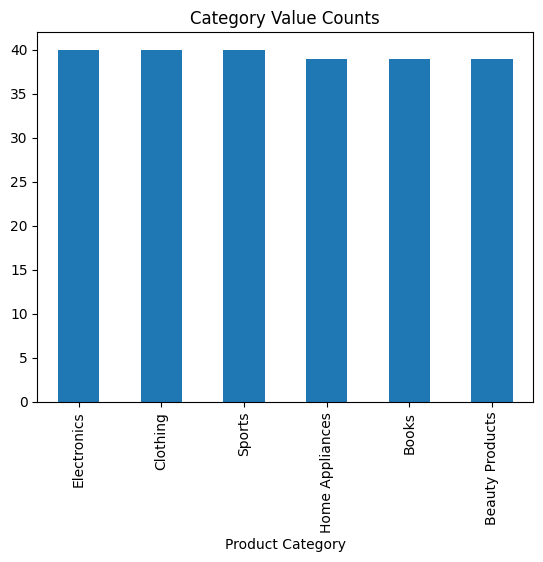

In [34]:
df["Product Category"].value_counts().plot(kind="bar", title="Category Value Counts")

array([<Axes: >], dtype=object)

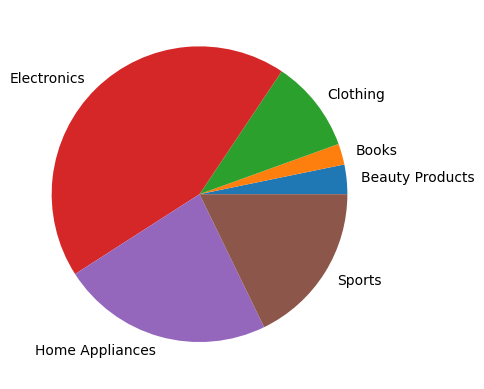

In [41]:
df.groupby("Product Category")["Total Revenue"].mean().plot(kind="pie", subplots=True)

<Axes: >

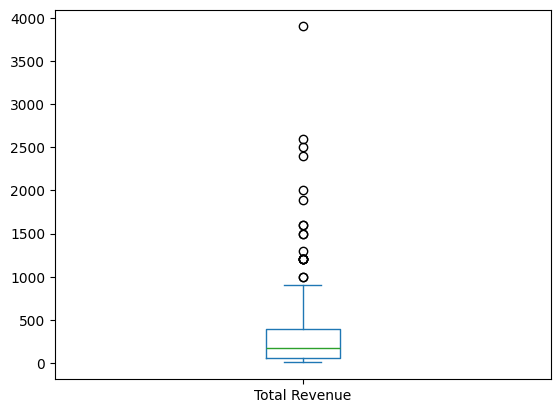

In [42]:
df["Total Revenue"].plot(kind="box")

<Axes: title={'center': 'Sales above Avg Value Counts'}, xlabel='Total Revenue'>

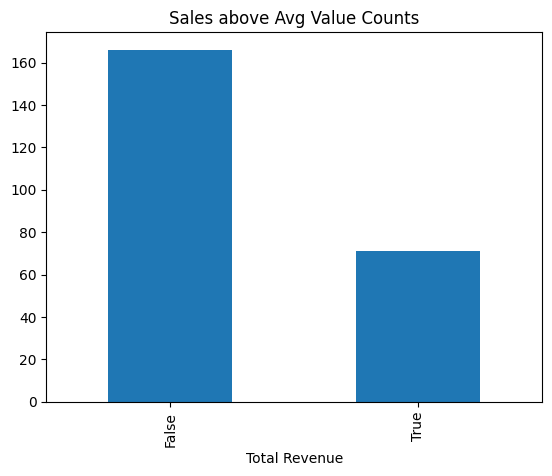

In [46]:
avg_sales = df["Total Revenue"].mean()
above_avg_sales = df["Total Revenue"].apply(lambda row: True if row>avg_sales else False)
above_avg_sales.value_counts().plot(kind="bar", title="Sales above Avg Value Counts")